# Visualize the M3 artifact — `lilylet/m3/notagenx-from-abc.pt`

Inspects the paired Lilylet-patch / ABC-M3-embedding dataset produced by
`tools/lilylet/preprocessLilyletM3.py`:

1. Overview & per-sample shapes
2. Patch-count distributions (Lilylet vs M3)
3. A single piece's M3 embedding heatmap
4. Mean-pooled M3 vectors — PCA scatter colored by period / genre
5. Cross-piece cosine-similarity matrix

Run from this directory (`tests/lilylet/`).


In [1]:
from pathlib import Path
import sys, collections

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'starry').is_dir())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import torch
import numpy as np
import matplotlib.pyplot as plt

ART = Path.home() / 'data/lilylet/m3/notagenx-from-abc.pt'
art = torch.load(ART, weights_only=False)
items = art['items']
print('format :', art['format'])
print('config :', {k: v for k, v in art['config'].items() if k != 'm3'})
print('m3     : hidden=%d patch_size=%d' % (art['config']['m3']['hidden'], art['config']['m3']['patch_size']))
print('stats  :', art['stats'])
print('items  :', len(items))


format : lilylet-m3-abc
config : {'patch_size': 64, 'patch_length': 2048, 'patch_stream': True}
m3     : hidden=768 patch_size=64
stats  : {'files': 215, 'paired': 215, 'missing_abc': 0, 'unknown_total': 0}
items  : 215


## Parse metadata from filenames

Filenames follow `DATE_TIME_Period_Composer_Genre_postinst.lyl`.

In [2]:
def parse_meta(path):
    parts = Path(path).stem.split('_')
    return dict(period=parts[2] if len(parts) > 2 else '?',
                composer=parts[3] if len(parts) > 3 else '?',
                genre=parts[4] if len(parts) > 4 else '?')

meta = [parse_meta(it['path']) for it in items]
periods = collections.Counter(m['period'] for m in meta)
genres = collections.Counter(m['genre'] for m in meta)
print('periods:', dict(periods))
print('genres :', dict(genres))


periods: {'Baroque': 2, 'Classical': 93, 'Romantic': 120}
genres : {'Keyboard': 134, 'Art Song': 12, 'Orchestral': 41, 'Chamber': 28}


## 1. Per-sample shapes

In [3]:
lyl_counts = np.array([it['patches'].shape[0] for it in items])
m3_counts = np.array([it['m3_patches'] for it in items])

print('Lilylet patches  min/median/max: %d / %d / %d' % (lyl_counts.min(), int(np.median(lyl_counts)), lyl_counts.max()))
print('M3      patches  min/median/max: %d / %d / %d' % (m3_counts.min(), int(np.median(m3_counts)), m3_counts.max()))
print('embedding dim:', items[0]['m3_embedding'].shape[1])
print()
for it in items[:5]:
    print('%-60s lyl=%-5s m3=%s' % (it['path'][:58], tuple(it['patches'].shape), tuple(it['m3_embedding'].shape)))


Lilylet patches  min/median/max: 34 / 204 / 2048
M3      patches  min/median/max: 98 / 288 / 5244
embedding dim: 768

20250408_163741_Baroque_Bach, Johann Sebastian_Keyboard_po   lyl=(156, 64) m3=(267, 768)
20250408_164339_Classical_Haydn, Joseph_Keyboard_postinst.   lyl=(226, 64) m3=(433, 768)
20250408_171004_Classical_Mozart, Wolfgang Amadeus_Keyboar   lyl=(223, 64) m3=(352, 768)
20250408_171712_Classical_Mozart, Wolfgang Amadeus_Keyboar   lyl=(280, 64) m3=(532, 768)
20250408_172011_Classical_Beethoven, Ludwig van_Keyboard_p   lyl=(125, 64) m3=(195, 768)


## 2. Patch-count distributions

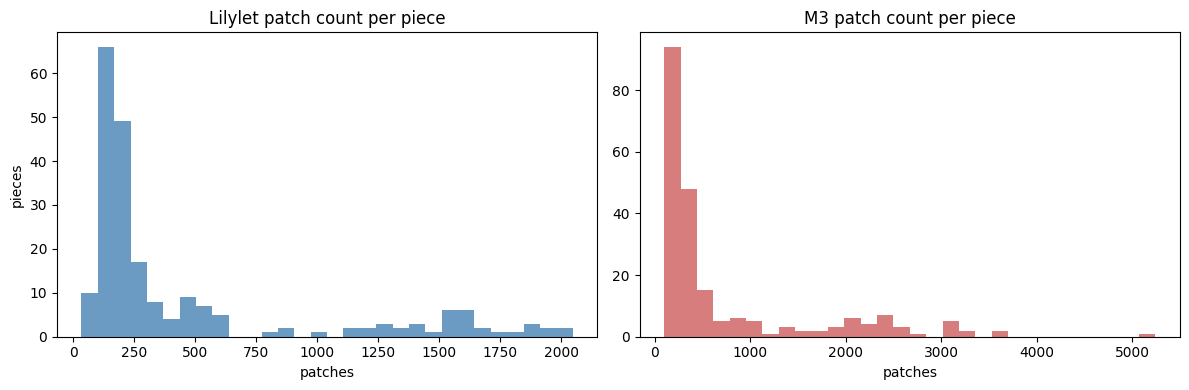

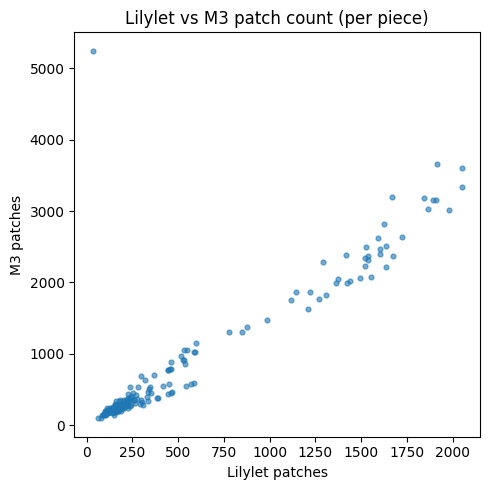

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(lyl_counts, bins=30, color='steelblue', alpha=0.8)
ax[0].set_title('Lilylet patch count per piece'); ax[0].set_xlabel('patches'); ax[0].set_ylabel('pieces')
ax[1].hist(m3_counts, bins=30, color='indianred', alpha=0.8)
ax[1].set_title('M3 patch count per piece'); ax[1].set_xlabel('patches')
plt.tight_layout(); plt.show()

plt.figure(figsize=(5, 5))
plt.scatter(lyl_counts, m3_counts, s=12, alpha=0.6)
plt.xlabel('Lilylet patches'); plt.ylabel('M3 patches')
plt.title('Lilylet vs M3 patch count (per piece)')
plt.tight_layout(); plt.show()


## 3. A single piece's M3 embedding

Heatmap of the un-pooled `[num_patches, 768]` embedding for one piece (patches on
the y-axis, the 768 feature dims on the x-axis).

20250408_163741_Baroque_Bach, Johann Sebastian_Keyboard_postinst.lyl -> (267, 768)


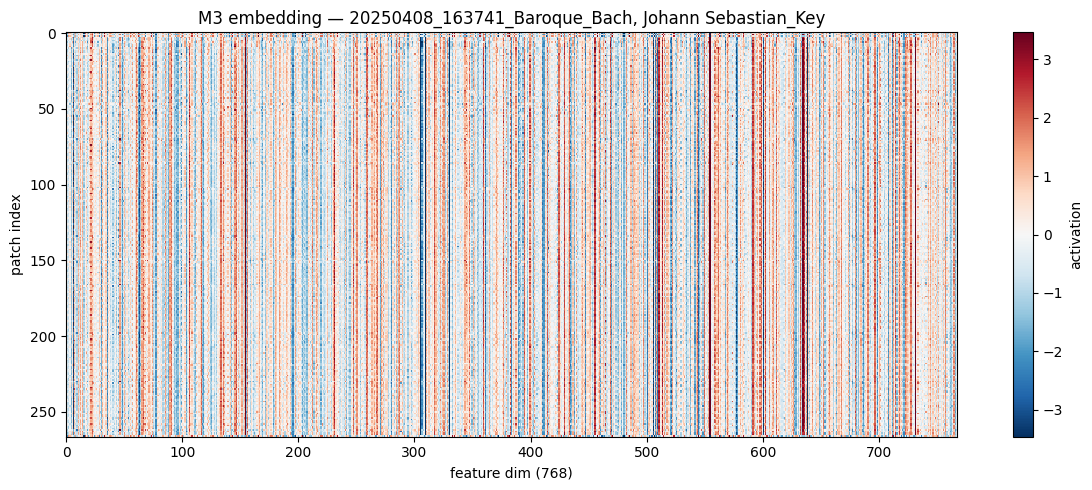

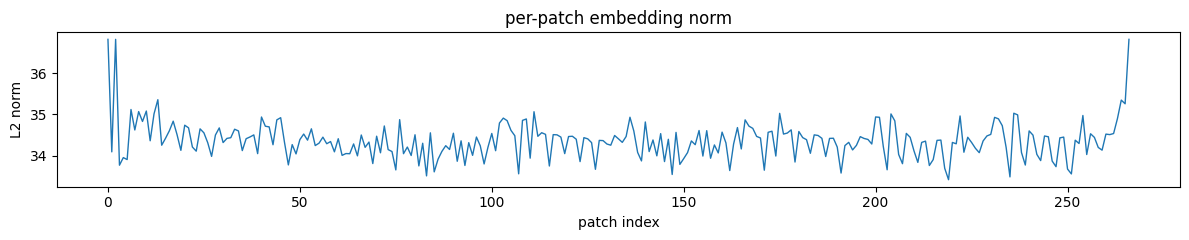

In [5]:
idx = 0
emb = items[idx]['m3_embedding'].float().numpy()
print(items[idx]['path'], '->', emb.shape)

plt.figure(figsize=(12, 5))
vmax = np.percentile(np.abs(emb), 99)
plt.imshow(emb, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax, interpolation='nearest')
plt.colorbar(label='activation'); plt.xlabel('feature dim (768)'); plt.ylabel('patch index')
plt.title('M3 embedding — %s' % Path(items[idx]['path']).stem[:50])
plt.tight_layout(); plt.show()

# per-patch L2 norm along the piece
plt.figure(figsize=(12, 2.5))
plt.plot(np.linalg.norm(emb, axis=1), lw=1)
plt.xlabel('patch index'); plt.ylabel('L2 norm'); plt.title('per-patch embedding norm')
plt.tight_layout(); plt.show()


## 4. Mean-pooled M3 vectors — PCA scatter

Pool each piece's M3 embedding to a single 768-d vector (mean over patches), then
project to 2-D with PCA (via torch SVD — no sklearn needed). Colored by period and genre.

In [6]:
# mean-pool each piece -> [N, 768]
pooled = torch.stack([it['m3_embedding'].float().mean(dim=0) for it in items])
print('pooled:', tuple(pooled.shape))

# PCA via SVD on centered data
X = pooled - pooled.mean(dim=0, keepdim=True)
U, S, Vh = torch.linalg.svd(X, full_matrices=False)
pcs = (X @ Vh[:2].T).numpy()
var = (S ** 2 / (S ** 2).sum())[:2].numpy()
print('explained variance PC1/PC2: %.1f%% / %.1f%%' % (var[0] * 100, var[1] * 100))


pooled: (215, 768)
explained variance PC1/PC2: 21.0% / 6.0%


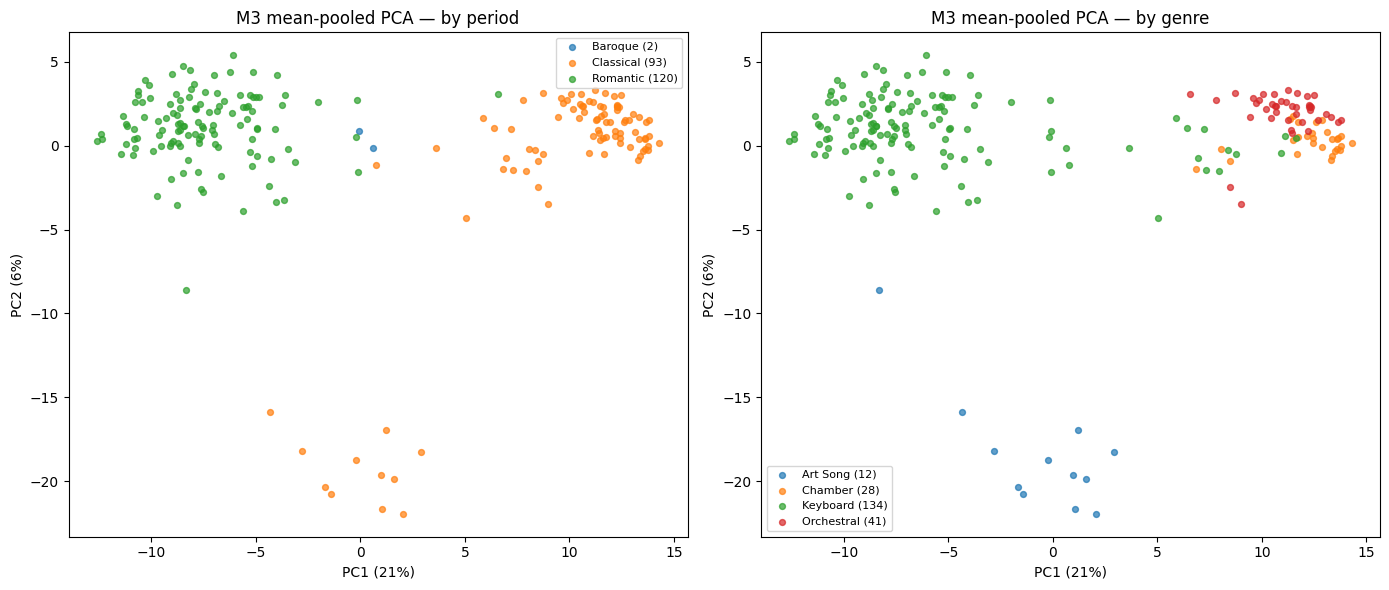

In [7]:
def scatter_by(key, ax):
    labels = [m[key] for m in meta]
    cats = sorted(set(labels))
    cmap = plt.get_cmap('tab10')
    for i, cat in enumerate(cats):
        sel = [j for j, l in enumerate(labels) if l == cat]
        ax.scatter(pcs[sel, 0], pcs[sel, 1], s=18, alpha=0.7, color=cmap(i % 10), label='%s (%d)' % (cat, len(sel)))
    ax.set_title('M3 mean-pooled PCA — by %s' % key)
    ax.set_xlabel('PC1 (%.0f%%)' % (var[0] * 100)); ax.set_ylabel('PC2 (%.0f%%)' % (var[1] * 100))
    ax.legend(fontsize=8)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
scatter_by('period', ax[0])
scatter_by('genre', ax[1])
plt.tight_layout(); plt.show()


## 5. Cross-piece cosine-similarity matrix

Cosine similarity between the mean-pooled vectors, sorted by period so block
structure (if any) is visible.

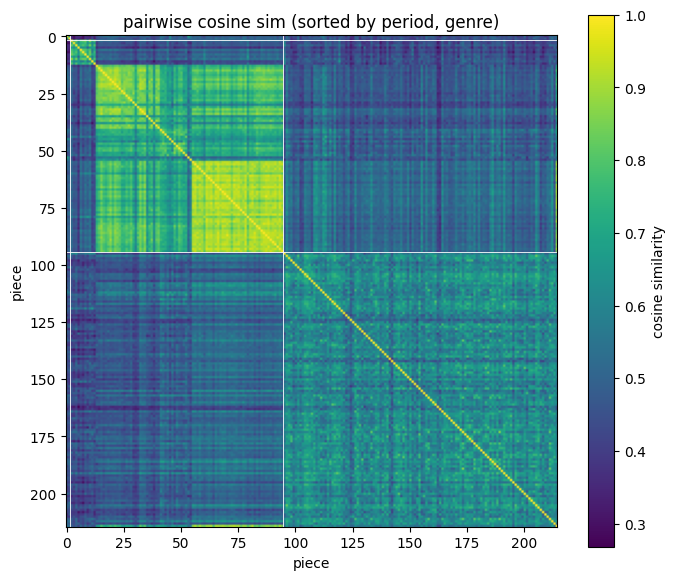

mean off-diagonal similarity: 0.572


In [8]:
order = sorted(range(len(items)), key=lambda j: (meta[j]['period'], meta[j]['genre']))
P = torch.nn.functional.normalize(pooled[order], dim=1)
sim = (P @ P.T).numpy()

plt.figure(figsize=(7, 6))
plt.imshow(sim, cmap='viridis')
plt.colorbar(label='cosine similarity')
plt.title('pairwise cosine sim (sorted by period, genre)')
plt.xlabel('piece'); plt.ylabel('piece')

# period boundary lines
sorted_periods = [meta[j]['period'] for j in order]
bounds = [k for k in range(1, len(sorted_periods)) if sorted_periods[k] != sorted_periods[k-1]]
for b in bounds:
    plt.axhline(b - 0.5, color='w', lw=0.6); plt.axvline(b - 0.5, color='w', lw=0.6)
plt.tight_layout(); plt.show()

print('mean off-diagonal similarity: %.3f' % sim[~np.eye(len(sim), dtype=bool)].mean())
